# Project: Finding Factors with PCA - Has Fama-French Stopped Working?

**Team Members:**
Anagha Athreyas | Luan De Souza | Dheemahi Guddekoppa Nagendra | Aathmika Anand Kandhaadai

In [167]:
import pandas as pd
import numpy as np
df = pd.read_csv("cubls91atntoty6y.csv", low_memory=False)
print(df.columns.tolist())
print(df.shape)
df.head()

['PERMNO', 'HdrCUSIP', 'PrimaryExch', 'SecurityType', 'SecuritySubType', 'Ticker', 'PERMCO', 'MthCalDt', 'MthCap', 'MthPrevPrc', 'MthRet']
(4947859, 11)


,PERMNO,HdrCUSIP,PrimaryExch,SecurityType,SecuritySubType,Ticker,PERMCO,MthCalDt,MthCap,MthPrevPrc,MthRet
0,10000,68391610,Q,EQTY,COM,OMFGA,7952,1986-01-31,16100.00,2.5625,0.707317
1,10000,68391610,Q,EQTY,COM,OMFGA,7952,1986-02-28,11960.00,4.3750,-0.257143
2,10000,68391610,Q,EQTY,COM,OMFGA,7952,1986-03-31,16330.00,3.2500,0.365385
3,10000,68391610,Q,EQTY,COM,OMFGA,7952,1986-04-30,15172.00,4.4375,-0.098592
4,10000,68391610,Q,EQTY,COM,OMFGA,7952,1986-05-30,11793.86,4.0000,-0.222656


In [168]:
# ── Step 1: Clean and Filter ──────────────────────────────

df.columns = df.columns.str.lower()
df['mthcaldt'] = pd.to_datetime(df['mthcaldt'])

# Filter training period: Jan 2010 – Dec 2025
df = df[(df['mthcaldt'] >= '2010-01-01') & (df['mthcaldt'] <= '2025-12-31')]

# Keep only common stocks (SecurityType == 'EQTY')
df = df[(df['securitytype'] == 'EQTY') & (df['securitysubtype'] == 'COM' )]

# Keep only US stock market (PrimaryExch == Q,N,A)
df = df[df['primaryexch'].isin(['Q','N','A'])]

# Keep only the stocks with market cap above 2B(mid-caps and above)
aux = df[(df.mthcaldt == '2024-12-31')]
df_ticker_50 = aux[aux.mthcap > 2000000].ticker
df = df[df.ticker.isin(df_ticker_50)]
df

,permno,hdrcusip,primaryexch,securitytype,securitysubtype,ticker,permco,mthcaldt,mthcap,mthprevprc,mthret
3711,10026,46603210,Q,EQTY,COM,JJSF,7976,2010-01-29,7.689695e+05,39.96,0.046296
3712,10026,46603210,Q,EQTY,COM,JJSF,7976,2010-02-26,7.855223e+05,41.81,0.021526
3713,10026,46603210,Q,EQTY,COM,JJSF,7976,2010-03-31,8.004566e+05,42.71,0.020266
3714,10026,46603210,Q,EQTY,COM,JJSF,7976,2010-04-30,8.579548e+05,43.47,0.071774
3715,10026,46603210,Q,EQTY,COM,JJSF,7976,2010-05-28,8.181784e+05,46.59,-0.046362
...,...,...,...,...,...,...,...,...,...,...,...
4947854,93436,88160R10,Q,EQTY,COM,TSLA,53453,2025-08-29,1.076881e+09,308.27,0.083044
4947855,93436,88160R10,Q,EQTY,COM,TSLA,53453,2025-09-30,1.478249e+09,333.87,0.332015
4947856,93436,88160R10,Q,EQTY,COM,TSLA,53453,2025-10-31,1.518436e+09,444.72,0.026623
4947857,93436,88160R10,Q,EQTY,COM,TSLA,53453,2025-11-28,1.430668e+09,456.56,-0.057802


In [169]:
# Keep only common stocks and clean returns
c = pd.to_numeric(df['mthret'], errors='coerce')
df = df.dropna(subset=['mthret'])

# ── Step 2: Build Return Matrix ──────────────────────────
ret_matrix = df.pivot_table(index='mthcaldt', columns='ticker', values='mthret')

# Keep only stocks with at least 60 months of data
ret_matrix = ret_matrix.dropna(thresh=60, axis=1)
ret_matrix = ret_matrix.fillna(0)
print(ret_matrix.shape)
ret_matrix.head()

(192, 1571)


ticker,A,AA,AAL,AAON,AAP,AAPL,AB,ABBV,ABCB,ABEV,...,Z,ZBH,ZBRA,ZG,ZIM,ZION,ZM,ZS,ZTO,ZTS
mthcaldt,,,,,,,,,,,,,,,,,,,,,
2010-01-29,-0.097844,-0.210298,0.0,0.056439,-0.025445,-0.088591,-0.083986,0.0,0.304469,0.0,...,0.0,0.0,-0.079365,0.0,0.0,0.478566,0.0,0.0,0.0,0.0
2010-02-26,0.122369,0.047100,0.0,0.021855,0.034221,0.065380,0.075848,0.0,0.017131,0.0,...,0.0,0.0,0.094636,0.0,0.0,-0.022124,0.0,0.0,0.0,0.0
2010-03-31,0.093134,0.070677,0.0,0.075095,0.028872,0.148470,0.133457,0.0,-0.042162,0.0,...,0.0,0.0,0.036052,0.0,0.0,0.177994,0.0,0.0,0.0,0.0
2010-04-30,0.054376,-0.056882,0.0,0.067639,0.075859,0.111021,0.023810,0.0,0.232558,0.0,...,0.0,0.0,-0.018581,0.0,0.0,0.315476,0.0,0.0,0.0,0.0
2010-05-28,-0.107557,-0.131197,0.0,0.021946,0.147672,-0.016125,-0.081837,0.0,0.012579,0.0,...,0.0,0.0,-0.053356,0.0,0.0,-0.166061,0.0,0.0,0.0,0.0


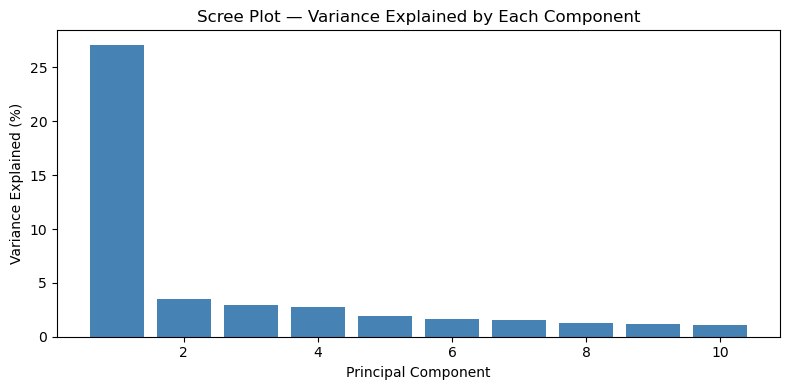

PC1: 27.10%
PC2: 3.48%
PC3: 2.98%
PC4: 2.79%
PC5: 1.97%
PC6: 1.63%
PC7: 1.52%
PC8: 1.25%
PC9: 1.20%
PC10: 1.13%


In [170]:
# ── Step 3: Standardize and Run PCA ──────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
ret_scaled = scaler.fit_transform(ret_matrix)

pca = PCA(n_components=10)
pca.fit(ret_scaled)

# Scree Plot
explained = pca.explained_variance_ratio_
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), explained * 100, color='steelblue')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot — Variance Explained by Each Component")
plt.tight_layout()
plt.savefig("scree_plot.png")
plt.show()

for i, val in enumerate(explained):
    print(f"PC{i+1}: {val*100:.2f}%")

---

## 1) Interpretation of Each Retained Principal Component

*Training Period:* January 2010 to December 2025, 16 years, 192 monthly observations
per stock. We start in 2010 to exclude the 2008-2009 financial crisis from distorting the
factor structure. Extending through 2025 ensures the most recent market regime, including
the AI investment cycle and the 2025 rate environment, is captured in the covariance
structure. The window spans four distinct regimes: the post-2010 bull market, the 2020
COVID shock and recovery, the 2022 rate hiking cycle, and the 2023-2025 AI-driven growth
period. We filter to stocks with market cap above $2B as of December 2024 to focus on
liquid, investable names with full return histories.

*Component Selection:* The scree plot shows a dominant PC1 at 27.10%, followed by a
sharp drop to PC2 at 3.48%. PC3 adds 2.98% and PC4 adds 2.79%. From PC5 onward each
component contributes less than 2% with no clear economic interpretation. The elbow after
PC1 is the primary cutoff. We retain four components because PC2 through PC4 each carry
distinct and interpretable economic meaning.

---

*PC1: Broad Market / Industrial-Financial Core (27.10%)*
Loads positively across almost all stocks in the universe. The highest-loading names are
industrials and diversified financials: PH (0.0404), AMP (0.0399), PRU (0.0394),
ITW (0.0393), PFG (0.0386). In a $2B and above universe, systematic market co-movement
is anchored by economically sensitive industrial and financial businesses rather than tech
alone. Near-zero and negative loadings, SLNO, ZM, SMMT, ZTO, BNTX, are niche biotech
and low-liquidity names with minimal sensitivity to broad economic cycles.
*PC1 = overall market factor.*

*PC2: Defensive Utilities vs Regional Banks/Energy (3.48%)*
A clean separation between regulated utilities and financial/energy names. High loadings:
CMS (0.0942), WEC (0.0936), AWK (0.0925), XEL (0.0865), ED (0.0839) — regulated
utilities with stable bond-like cash flows that benefit from lower rates. Negative
loadings: WTFC (-0.0555), CFG (-0.0552), TCBI (-0.0543), COP (-0.0534), HP (-0.0532);
regional banks and energy names that benefit from higher rates and economic activity.
*PC2 = defensive income vs cyclical financial/energy exposure.*

*PC3: Growth Tech / AI vs Defensive Staples (2.98%)*
The most economically distinctive factor in this universe. High loadings: DDOG (0.0854),
NET (0.0842), ZS (0.0827), ESTC (0.0793), CRWD (0.0761), cloud infrastructure,
cybersecurity, and SaaS names driven by AI adoption and enterprise software spend.
Negative loadings: AVA (-0.0606), NWE (-0.0556), CPB (-0.0554), ED (-0.0547),
ALL (-0.0545) — regulated utilities and consumer staples with low-growth, defensive
cash flows. Extending the training period through 2025 brings the AI investment cycle
into the factor structure, and PC3 cleanly captures the return separation between
high-growth digital businesses and low-growth defensive names.
*PC3 = AI-driven growth tech vs defensive staples.*

*PC4: Energy/Real Assets vs Industrials (2.79%)*
High loadings: OVV (0.0793), VTR (0.0724), WELL (0.0724), BRX (0.0713), MGY (0.0711),
energy producers and REITs with cash flows tied to physical assets and commodity cycles.
Negative loadings: CNH (-0.0656), GGG (-0.0642), ODFL (-0.0564), INFA (-0.0530),
QGEN (-0.0529); industrial equipment and logistics names with more stable, volume-driven
revenues. *PC4 = real asset/energy exposure vs industrial services.*

---

In [171]:
# ── Step 4: Extract Loadings ──────────────────────────────
n_components = 4

loadings = pd.DataFrame(
    pca.components_[:n_components].T,
    index=ret_matrix.columns,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

top = loadings.apply(lambda col: col.nlargest(5).reset_index().apply(lambda r: f"{r['ticker']} ({r[col.name]:.4f})", axis=1))
bot = loadings.apply(lambda col: col.nsmallest(5).reset_index().apply(lambda r: f"{r['ticker']} ({r[col.name]:.4f})", axis=1))

top.index = pd.RangeIndex(1, 6)
bot.index = pd.RangeIndex(1, 6)

summary_table = pd.concat([top, bot], keys=['Top 5', 'Bottom 5'])
summary_table.index.names = ['Group', 'Rank']
summary_table


PC1             PC2            PC3             PC4
Group    Rank                                                               
Top 5    1        PH (0.0404)    CMS (0.0942)  DDOG (0.0854)    OVV (0.0793)
         2       AMP (0.0399)    WEC (0.0936)   NET (0.0842)    VTR (0.0724)
         3       PRU (0.0394)    AWK (0.0925)    ZS (0.0827)   WELL (0.0724)
         4       ITW (0.0393)    XEL (0.0865)  ESTC (0.0793)    BRX (0.0713)
         5       PFG (0.0386)     ED (0.0839)  CRWD (0.0761)    MGY (0.0711)
Bottom 5 1     SLNO (-0.0037)  WTFC (-0.0555)  AVA (-0.0606)   CNH (-0.0656)
         2       ZM (-0.0013)   CFG (-0.0552)  NWE (-0.0556)   GGG (-0.0642)
         3     SMMT (-0.0005)  TCBI (-0.0543)  CPB (-0.0554)  ODFL (-0.0564)
         4       ZTO (0.0000)   COP (-0.0534)   ED (-0.0547)  INFA (-0.0530)
         5      BNTX (0.0008)    HP (-0.0532)  ALL (-0.0545)  QGEN (-0.0529)

---

## 2) View on Each Factor — Direction and Economic Reasoning

*PC1: Slight positive (weight: 0.3)*
Broad market beta contributes positive expected return over any holding period. Over a
one-week window however, general market direction is largely noise. We keep a small
positive weight but do not rely on it as the primary driver.

*PC2: Neutral (excluded)*
Both sides carry binary risk within a single week. Utilities react sharply to any rate or
inflation data release. Regional banks move on credit news. No clear directional edge so
we exclude PC2 entirely.

*PC3: Strong positive (weight: 0.7)*
This is our primary bet and carries the highest weight. Two reasons:

1. *AI narrative:* The AI investment cycle is the dominant market theme heading into
   the performance window. Hyperscalers continue to reaffirm capex commitments.
   Enterprise cybersecurity and cloud infrastructure spending is accelerating as companies
   scale AI workloads. DDOG, NET, ZS, CRWD, and ESTC are direct beneficiaries of this
   spend cycle and move on AI-related news flow in the short term.

2. *Geopolitics:* US-China trade tensions and semiconductor export controls create
   specific downside risk for hardware-exposed names. Cloud and SaaS businesses have
   minimal direct exposure to these restrictions, making them relatively insulated from
   geopolitical headline risk. Defensive staples on the negative side of PC3 face
   headwinds from low growth expectations and limited upside catalysts.

Over a one-week performance window, thematic momentum and news flow drive returns more
than long-run factor exposure. PC3 is where we have the clearest and most current
directional conviction.

*PC4: Neutral (excluded)*
PC4 separates energy/REITs from industrials. We do not take a strong directional view on
this axis over one week given mixed signals on commodity prices and industrial demand.
Excluded from scoring.

---

In [172]:
# -- Step 5: Build Portfolio --------------------------------------------------
# View: PC1 (broad market) slight positive + PC3 (growth tech vs defensive staples) strong positive
# Short one-week horizon -- overweight PC3 to capture AI/cloud thematic momentum
# Geopolitical risk (export controls) favors software/cloud over hardware semis and defensive names

loadings['score'] = loadings['PC1'] * 0.3 + loadings['PC3'] * 0.7

# Top 30 stocks by score — long only, equal weighted
portfolio = loadings.nlargest(30, 'score')
tickers = portfolio.index.tolist()

print(f"\nTotal stocks: {len(tickers)}")
print("\nPortfolio loadings:")

portfolio[['PC1', 'PC2', 'PC3', 'PC4', 'score']].sort_values('score', ascending=False)


Total stocks: 30

Portfolio loadings:


,PC1,PC2,PC3,PC4,score
ticker,,,,,
DDOG,0.012577,0.009574,0.085397,0.007230,0.063551
NET,0.008975,-0.001630,0.084160,-0.010789,0.061604
ZS,0.008107,0.015412,0.082681,-0.011989,0.060309
ESTC,0.013320,-0.006131,0.079277,0.004806,0.059490
HUBS,0.023340,-0.006624,0.074030,0.005264,0.058823
CVNA,0.018396,-0.001629,0.075326,0.008708,0.058247
SHOP,0.022353,0.023125,0.073573,0.016385,0.058207
TWLO,0.014623,0.002014,0.074095,0.000493,0.056254
CRWD,0.009031,0.006522,0.076110,0.012670,0.055986


We underweight PC1 given the short horizon and overweight PC3 where we have the highest conviction based on the AI investment backdrop and current geopolitical environment.

---

## 3) Why the Selected Stocks Match Our View

The formula selects for high PC3 loadings, naturally producing a portfolio concentrated
in cloud infrastructure, cybersecurity, and AI-adjacent software, directly tied to the
thesis. The top-scoring names confirm this:

- *DDOG (PC3 0.0854)* — observability and monitoring platform, accelerating spend as
  enterprises scale AI workloads across cloud infrastructure
- *NET (PC3 0.0842)* — cloud networking and security, direct beneficiary of rising AI
  traffic volumes and zero-trust security adoption
- *ZS (PC3 0.0827)* — enterprise cloud security platform, benefits from AI-driven
  security spend and shift away from hardware-based security
- *ESTC (PC3 0.0793)* — search and observability infrastructure, seeing increased
  adoption as AI applications require real-time data pipelines
- *CRWD (PC3 0.0761)* — leading cybersecurity platform, direct beneficiary of
  enterprise AI security budgets and threat landscape expansion

Names scoring primarily through PC1 — industrials and diversified financials — add broad
market diversification without diluting the core AI and cloud software thesis.

---

## 4) Sector Composition and Whether It Was Intentional

The portfolio concentrates in cloud software, cybersecurity, and AI infrastructure.
This was not manually selected, it is a direct output of scoring on PC3. Because PC3
in this updated universe captures the growth tech versus defensive axis, the
highest-scoring names naturally cluster in SaaS and cloud infrastructure.

We are comfortable with this concentration for the one-week window given the strength
of the AI investment narrative. The main risk is a sharp risk-off move, a hawkish Fed
statement, a trade escalation, or a broad selloff in high-multiple growth names, which
would affect the majority of the portfolio simultaneously. That is the explicit
trade-off of a concentrated thematic factor view over a short window.

---

*Portfolio Tickers:* DDOG, NET, ZS, ESTC, HUBS, CVNA, SHOP, TWLO, CRWD, AFRM, DOCU, OKTA, SQ, TWST, MDB, SPOT, TTD, TEAM, ASAN, CRSP, RNG, COIN, NOVT, W,
MRVL, DASH, KEYS, PYPL, BILL, ZG